# hHDAC8 Docking-Selective Inhibitor Generation Pipeline

End-to-end notebook: loads trained models, runs the docking-selective GA across all ZBG
lineages, assembles/gates/clusters the results, generates figures, and provides
`predict_from_smiles()` for scoring arbitrary compounds.

**Requirements before running:**
- `pipeline.py` and `ga.py` (updated versions from the tarball) in the same directory as this notebook, or on `sys.path`
- `run_state.pkl` (from `models/` in the original repo) in the same directory — contains the 6 pre-trained model bundles

**New vs. original notebook:** adds docking-score-based isoform selectivity as a Pareto
objective + directional threshold gate. HDAC8 docking target: ≤ -7 (strong). HDAC1/HDAC6
docking target: > -7 (weak). See Section 2 for details.


## 0. Setup

In [2]:
import sys, os, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.ML.Cluster import Butina

# pipeline.py and ga.py must be in the same directory as this notebook
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

from pipeline import (descriptors_from_mol, compute_liability_flags, passes_tier1_gates,
                       is_hydroxamate, passes_lipinski_veber, morgan_fp, morgan_fp_bitvect,
                       max_training_similarity, AD_HARD_THRESHOLD, compute_zbg_precedent_counts,
                       ZBG_PRECEDENT_MIN, ic50_tier, rough_2d_l_shape_proxy, ZBG_TAGS,
                       predict_batch)
from ga import (run_ga_pareto, passes_docking_selectivity_gate, passes_ic50_selectivity_gate,
                HDAC8_DOCK_MAX, OFFTARGET_DOCK_MIN, DOCK_AD_FLOOR,
                OFFTARGET_IC50_MIN_NM, MIN_SELECTIVITY_LOG)

print("All imports OK")
print(f"Docking gate: HDAC8 <= {HDAC8_DOCK_MAX} (strong), HDAC1/HDAC6 > {OFFTARGET_DOCK_MIN} (weak), AD floor {DOCK_AD_FLOOR}")
print(f"IC50 selectivity flag: off-target IC50 >= {OFFTARGET_IC50_MIN_NM} nM and >= {MIN_SELECTIVITY_LOG} log margin")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
All imports OK
Docking gate: HDAC8 <= -7.0 (strong), HDAC1/HDAC6 > -7.0 (weak), AD floor -13.0
IC50 selectivity flag: off-target IC50 >= 1000.0 nM and >= 0.7 log margin


## 1. Load trained models

### (Optional) Retrain all six models from scratch

The shipped `run_state.pkl` already contains trained models, so **you can skip this cell** and just load them below. Run this **only** if you want to regenerate the models from the CSVs in `../data/` (e.g. after adding data). It retrains all six (HDAC8/1/6 IC50 + HDAC8/1/6 docking) with scaffold-grouped 5-fold CV and overwrites `../models/run_state.pkl`. Takes a few minutes on 1 CPU.

Set `RETRAIN = True` to run it.

In [3]:
RETRAIN = True   # set True to retrain all six models from ../data/ and rebuild run_state.pkl

if RETRAIN:
    import subprocess, sys as _sys
    # train_all_models.py lives in ../scripts (already on sys.path); call it as a module
    from train_all_models import main as _train_main
    _sys.argv = ['train_all_models.py', '--data-dir', os.path.join('..', 'data'),
                 '--out', os.path.join('..', 'models', 'run_state.pkl')]
    _train_main()
    print("Retrained and rebuilt ../models/run_state.pkl")
else:
    print("Skipping retrain — using existing ../models/run_state.pkl")

Retraining all six models (scaffold-grouped 5-fold CV):
  [ic50_bundle] scaffold-CV R2 = 0.534 (+/- 0.036), n = 6082
  [dock_bundle] scaffold-CV R2 = 0.417 (+/- 0.038), n = 11036
  [hdac1_bundle] scaffold-CV R2 = 0.511 (+/- 0.056), n = 10340
  [hdac6_bundle] scaffold-CV R2 = 0.491 (+/- 0.029), n = 9035
  [hdac1_dock_bundle] scaffold-CV R2 = 0.190 (+/- 0.059), n = 946
  [hdac6_dock_bundle] scaffold-CV R2 = 0.225 (+/- 0.112), n = 1003

Summary (scaffold-CV R2):
  ic50_bundle        R2=0.534  n=6,082
  dock_bundle        R2=0.417  n=11,036
  hdac1_bundle       R2=0.511  n=10,340
  hdac6_bundle       R2=0.491  n=9,035
  hdac1_dock_bundle  R2=0.190  n=946
  hdac6_dock_bundle  R2=0.225  n=1,003

Saved ../models/run_state.pkl  (ic50_df: 6,082 HDAC8 IC50 rows)
Retrained and rebuilt ../models/run_state.pkl


In [4]:
with open(os.path.join('..', 'models', 'run_state.pkl'), 'rb') as f:
    st = pickle.load(f)

ic50_bundle   = st['ic50_bundle']
dock_bundle   = st['dock_bundle']
hdac1_bundle  = st['hdac1_bundle']
hdac6_bundle  = st['hdac6_bundle']
hdac1_dock_bundle = st['hdac1_dock_bundle']
hdac6_dock_bundle = st['hdac6_dock_bundle']
ic50_df       = st['ic50_df']

print(f"HDAC8 IC50 model:    CV R² = {ic50_bundle['cv_r2']:.3f}, train n = {len(ic50_bundle['train_fps'])}")
print(f"HDAC8 docking model: CV R² = {dock_bundle['cv_r2']:.3f}, train n = {len(dock_bundle['train_fps'])}")
print(f"HDAC1 IC50 model:    CV R² = {hdac1_bundle['cv_r2']:.3f}, train n = {len(hdac1_bundle['train_fps'])}")
print(f"HDAC6 IC50 model:    CV R² = {hdac6_bundle['cv_r2']:.3f}, train n = {len(hdac6_bundle['train_fps'])}")
print(f"HDAC1 docking model: CV R² = {hdac1_dock_bundle['cv_r2']:.3f}, train n = {len(hdac1_dock_bundle['train_fps'])}")
print(f"HDAC6 docking model: CV R² = {hdac6_dock_bundle['cv_r2']:.3f}, train n = {len(hdac6_dock_bundle['train_fps'])}")
print(f"\nHDAC8 IC50 training set: {len(ic50_df)} compounds")


HDAC8 IC50 model:    CV R² = 0.534, train n = 6082
HDAC8 docking model: CV R² = 0.417, train n = 11036
HDAC1 IC50 model:    CV R² = 0.511, train n = 10340
HDAC6 IC50 model:    CV R² = 0.491, train n = 9035
HDAC1 docking model: CV R² = 0.190, train n = 946
HDAC6 docking model: CV R² = 0.225, train n = 1003

HDAC8 IC50 training set: 6082 compounds


## 2. Docking + IC50 selectivity gate — what changed

**Docking gate (hard, defines a qualifying hit):**
- HDAC8 predicted docking must be **≤ -7** (strong on-target binding), and not below a -13 applicability-domain floor.
- HDAC1 and HDAC6 predicted docking must each be **> -7** (weak off-target binding).

This is a clean directional threshold per isoform — simpler and more interpretable than the earlier ±1.5 tolerance band.

**IC50 selectivity (reported + preferred, not a hard hit gate):**
- Off-target predicted IC50 ≥ 1000 nM and HDAC8 ≥ 0.7 log more potent than each off-target → `passes_ic50_selectivity` flag.
- This is **not** folded into the hard hit gate. It was tried as a hard gate and proved far too strict (HDAC8's own median training IC50 is ~920 nM, so requiring it to beat weak off-targets collapsed yield to ~1 hit/lineage). Instead the existing `selectivity` Pareto objective pushes the search toward IC50-selective molecules, and the flag is enforced only where a fully-selective subset is wanted.

**GA mechanics:** `evaluate_candidate()` computes `docking_selectivity = min(dock_HDAC1, dock_HDAC6) - dock_HDAC8` as a Pareto objective (maximized alongside pIC50 / HDAC8 dock / liability / IC50-selectivity), and sets `passes_dock_gate`. The gate is **not** a hard rejection inside the GA — that would freeze lineages whose seeds start outside the target region. It gates only what counts as a returned hit; the Pareto objective is what drives the population toward selectivity across generations.

## 3. Configuration

In [5]:
# GA parameters
GENERATIONS_PER_STAGE = 55     # per stage (2 stages per lineage)
POP_SIZE = 100
MAX_IC50_NM = 500              # pIC50 threshold for "hit" (legacy, kept for compatibility)
MAX_DOCKING_SCORE = -7.0       # HDAC8 docking threshold for "hit" (legacy)
MAX_HITS_PER_ISLAND = 60       # cap per lineage to prevent pool domination
CLUSTER_CUTOFF = 0.4           # Butina clustering Tanimoto distance cutoff
QUOTA_PER_CELL = 3             # balanced deliverable: up to this many per (ZBG, tier)
QUOTA_REPS = 4                 # cluster-rep deliverable: this many per lineage

SYNTHETIC_SEEDS = {
    'Salicylamide':      'Oc1ccccc1C(=O)NCCN1CCN(Cc2c[nH]c3ccccc23)CC1',
    '3-HPT':             'CCN2CCN(Cc3c[nH]c4ccccc34)CC2n1c(=S)c(O)ccc1',
    'Triazolopyridine':  'c1ccn2cnnc2c1CCN1CCN(Cc2c[nH]c3ccccc23)CC1',
}
ALL_LINEAGES = [name for name, _ in ZBG_TAGS]
print(f"ZBG lineages to search: {ALL_LINEAGES}")


ZBG lineages to search: ['Salicylamide', 'Ortho-aminoanilide', 'Acylurea', '3-HPT', 'Carboxylate', 'Trifluoromethyl-ketone', 'Cyclic-thione', 'Triazoloquinoline', 'Triazolopyridine']


## 4. Helper functions

In [6]:
def zbg_of(smi):
    m = Chem.MolFromSmiles(smi)
    return compute_liability_flags(m)['zbg_tag'] if m else None

def tier1_ok(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return False
    ok, _ = passes_tier1_gates(m, descriptors_from_mol(m), compute_liability_flags(m))
    return ok

def butina_cluster(fps, cutoff=CLUSTER_CUTOFF):
    n = len(fps)
    dists = []
    for i in range(1, n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - s for s in sims])
    return Butina.ClusterData(dists, n, cutoff, isDistData=True)

def quota_by_cell(df, quota, group_cols, sort_col='pIC50_pred'):
    parts = [grp.sort_values(sort_col, ascending=False).head(quota)
             for _, grp in df.groupby(group_cols)]
    if not parts: return df.iloc[0:0]
    return pd.concat(parts).sort_values(
        list(group_cols) + [sort_col],
        ascending=[True]*len(group_cols) + [False]).reset_index(drop=True)

non_hydrox = ic50_df[~ic50_df['is_hydroxamate']]
print(f"Non-hydroxamate training compounds: {len(non_hydrox)}")


Non-hydroxamate training compounds: 2354


## 5. Run the GA — one island per ZBG lineage

By default this cell **loads the already-computed hit pool** from `../models/docking_selective_run_state.pkl` so "Run All" completes in seconds and reproduces the shipped results exactly. Set `REGENERATE = True` to actually re-run the full two-stage island GA across all nine ZBG lineages (~25 min on 1 CPU) — the search is stochastic-but-seeded, so a fresh run lands in the same region, not necessarily byte-identical.

In [8]:
def run_island(lineage):
    real = [(s, p) for s, p in zip(non_hydrox['canonical_smiles'], non_hydrox['pIC50'])
            if zbg_of(s) == lineage and tier1_ok(s)]
    real_df = pd.DataFrame(real, columns=['smi','pIC50']) if real else pd.DataFrame(columns=['smi','pIC50'])
    seeds = real_df.sort_values('pIC50', ascending=False)['smi'].head(10).tolist()
    if lineage in SYNTHETIC_SEEDS:
        seeds = seeds + [SYNTHETIC_SEEDS[lineage]]

    print(f"\n--- Island: {lineage} ({len(real_df)} real seeds available, {len(seeds)} used) ---")
    if not seeds:
        print(f"  No seeds for {lineage}, skipping.")
        return {}

    t0 = time.time()
    _, evaluated, hits = run_ga_pareto(
        seeds, ic50_bundle, dock_bundle, max_ic50_nM=MAX_IC50_NM,
        max_docking_score=MAX_DOCKING_SCORE, generations=GENERATIONS_PER_STAGE,
        pop_size=POP_SIZE, protect_lineages=False,
        hdac1_bundle=hdac1_bundle, hdac6_bundle=hdac6_bundle,
        hdac1_dock_bundle=hdac1_dock_bundle, hdac6_dock_bundle=hdac6_dock_bundle)
    print(f"  stage 1: {len(hits)} hits ({time.time()-t0:.0f}s)")

    if evaluated:
        eval_df = pd.DataFrame(evaluated)
        stage2_seeds = eval_df.sort_values('pic50', ascending=False)['smi'].head(15).tolist()
        t0 = time.time()
        _, _, hits2 = run_ga_pareto(
            stage2_seeds, ic50_bundle, dock_bundle, max_ic50_nM=MAX_IC50_NM,
            max_docking_score=MAX_DOCKING_SCORE, generations=GENERATIONS_PER_STAGE,
            pop_size=POP_SIZE, protect_lineages=False,
            hdac1_bundle=hdac1_bundle, hdac6_bundle=hdac6_bundle,
            hdac1_dock_bundle=hdac1_dock_bundle, hdac6_dock_bundle=hdac6_dock_bundle)
        hits.update(hits2)
        print(f"  stage 2 (breeding): {len(hits)} combined ({time.time()-t0:.0f}s)")

    true_hits = {smi: res for smi, res in hits.items() if res['zbg_tag'] == lineage}
    print(f"  {len(true_hits)} genuinely still match {lineage} after drift filter")
    if len(true_hits) > MAX_HITS_PER_ISLAND:
        true_hits = dict(sorted(true_hits.items(), key=lambda kv: -kv[1]['pic50'])[:MAX_HITS_PER_ISLAND])
    return true_hits


In [10]:
REGENERATE = True   # set True to re-run the full GA (~25 min); False loads cached hits

if REGENERATE:
    t_total = time.time()
    all_hits = {}
    for lineage in ALL_LINEAGES:
        all_hits[lineage] = run_island(lineage)
    print("\n=== Island summary ===")
    for lineage, hits in all_hits.items():
        print(f"  {lineage}: {len(hits)} hits")
    print(f"\nTotal GA time: {time.time()-t_total:.0f}s")
    _regenerated = True
else:
    # Load the cached hit pool; downstream cells rebuild everything from full_df.
    with open(os.path.join('..', 'models', 'docking_selective_run_state.pkl'), 'rb') as f:
        _cached = pickle.load(f)
    full_df = _cached['hits_df'].copy()
    _regenerated = False
    print(f"Loaded cached hit pool: {len(full_df)} hits across {full_df['zbg_tag'].nunique()} ZBG lineages")
    print(full_df['zbg_tag'].value_counts())


--- Island: Salicylamide (2 real seeds available, 3 used) ---
Gen  1: survived Tier-1=100  front-0=100  best pIC50=6.163  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  2: survived Tier-1= 87  front-0= 23  best pIC50=6.379  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  3: survived Tier-1= 80  front-0= 34  best pIC50=6.379  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  4: survived Tier-1= 78  front-0= 34  best pIC50=6.419  meeting-bounds-this-gen=1  elite-lineages={'Salicylamide': 30}
Gen  5: survived Tier-1= 73  front-0= 41  best pIC50=6.419  meeting-bounds-this-gen=2  elite-lineages={'Salicylamide': 30}
Gen  6: survived Tier-1= 78  front-0= 45  best pIC50=6.694  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  7: survived Tier-1= 79  front-0= 52  best pIC50=6.694  meeting-bounds-this-gen=0  elite-lineages={'Salicylamide': 30}
Gen  8: survived Tier-1= 84  front-0= 46  best pIC50=6.694  meeting-bounds-t

## 6. Assemble, AD-gate, precedent-check, cluster

In [11]:
if _regenerated:
    rows = []
    for lineage, hits in all_hits.items():
        for smi, res in hits.items():
            ic50_nm = 10 ** (9 - res['pic50'])
            rows.append({
                'SMILES': smi, 'pIC50_pred': res['pic50'], 'IC50_nM_est': ic50_nm,
                'IC50_tier': ic50_tier(ic50_nm),
                'docking_pred': res['dock'], 'zbg_tag': res['zbg_tag'],
                'pains_brenk_flagged': res['pains_brenk_flagged'],
                'soft_metabolic_liability': res['soft_metabolic_liability'],
                'sa_score': res['sa_score'],
                'MW': res.get('mw'), 'cLogP': res.get('clogp'), 'HBD': res.get('hbd'),
                'HBA': res.get('hba'), 'TPSA': res.get('tpsa'), 'RotB': res.get('rotb'),
                'l_shape_2d_proxy': rough_2d_l_shape_proxy(Chem.MolFromSmiles(smi)),
                'pIC50_hdac1_pred': res.get('pic50_hdac1'),
                'pIC50_hdac6_pred': res.get('pic50_hdac6'),
                'selectivity_vs_hdac1': (res['pic50'] - res['pic50_hdac1']) if res.get('pic50_hdac1') is not None else None,
                'selectivity_vs_hdac6': (res['pic50'] - res['pic50_hdac6']) if res.get('pic50_hdac6') is not None else None,
                'docking_hdac1_pred': res.get('dock_hdac1'),
                'docking_hdac6_pred': res.get('dock_hdac6'),
                'docking_selectivity': res.get('docking_selectivity'),
                'passes_ic50_selectivity': res.get('passes_ic50_selectivity'),
            })
    
    full_df = pd.DataFrame(rows).drop_duplicates(subset='SMILES').sort_values('pIC50_pred', ascending=False).reset_index(drop=True)
    print(f"Full pool: {len(full_df)}")
    print(full_df['zbg_tag'].value_counts())
else:
    print(f'Using cached full_df: {len(full_df)} rows')

Full pool: 212
zbg_tag
Triazolopyridine          60
Cyclic-thione             60
Acylurea                  60
3-HPT                     28
Trifluoromethyl-ketone     4
Name: count, dtype: int64


In [12]:
if _regenerated:
    # Applicability domain
    full_df['ic50_model_max_similarity'] = full_df['SMILES'].apply(
        lambda s: max_training_similarity(Chem.MolFromSmiles(s), ic50_bundle['train_fps'], nbits=ic50_bundle['nbits']))
    full_df['dock_model_max_similarity'] = full_df['SMILES'].apply(
        lambda s: max_training_similarity(Chem.MolFromSmiles(s), dock_bundle['train_fps'], nbits=dock_bundle['nbits']))
    full_df['ic50_model_low_confidence'] = full_df['ic50_model_max_similarity'] < 0.35
    full_df['dock_model_low_confidence'] = full_df['dock_model_max_similarity'] < 0.35
    before_ad = len(full_df)
    full_df = full_df[full_df['ic50_model_max_similarity'] >= AD_HARD_THRESHOLD].reset_index(drop=True)
    print(f"AD hard-reject: removed {before_ad - len(full_df)}")
    
    # ZBG precedent
    zbg_precedent_counts = compute_zbg_precedent_counts(ic50_df['canonical_smiles'].tolist())
    full_df['zbg_precedent_count'] = full_df['zbg_tag'].map(zbg_precedent_counts).fillna(0).astype(int)
    full_df['zbg_low_precedent'] = full_df['zbg_precedent_count'] < ZBG_PRECEDENT_MIN
    
    # Real-ceiling check
    real_rows = [(zbg_of(s), p) for s, p in zip(non_hydrox['canonical_smiles'], non_hydrox['pIC50']) if tier1_ok(s)]
    ceilings = pd.DataFrame(real_rows, columns=['zbg','pIC50']).groupby('zbg')['pIC50'].max()
    full_df['zbg_real_pic50_ceiling'] = full_df['zbg_tag'].map(ceilings)
    full_df['exceeds_real_precedent'] = full_df['pIC50_pred'] > full_df['zbg_real_pic50_ceiling']
    print(f"Exceeds real precedent: {full_df['exceeds_real_precedent'].sum()} / {len(full_df)}")
    
else:
    pass  # cached full_df already carries these columns

AD hard-reject: removed 0
Exceeds real precedent: 68 / 212


In [13]:
if _regenerated:
    # Butina clustering
    if len(full_df) >= 2:
        hit_mols = [Chem.MolFromSmiles(s) for s in full_df['SMILES']]
        hit_fps = [morgan_fp_bitvect(m) for m in hit_mols]
        clusters = butina_cluster(hit_fps)
        cluster_id = [None] * len(full_df)
        for cid, idxs in enumerate(clusters):
            for idx in idxs:
                cluster_id[idx] = cid
        full_df['cluster_id'] = cluster_id
    else:
        full_df['cluster_id'] = 0
    full_df['cluster_size'] = full_df['cluster_id'].map(full_df['cluster_id'].value_counts())
    print(f"{full_df['cluster_id'].nunique()} structural clusters")
    
else:
    pass  # cached full_df already carries these columns

33 structural clusters


## 7. Export deliverables

In [15]:
# Raw pool
full_df.to_csv(os.path.join('..', 'candidates', 'ga_candidates_RAW.csv'), index=False)

# Balanced by (ZBG, tier)
balanced = quota_by_cell(full_df, QUOTA_PER_CELL, ['zbg_tag', 'IC50_tier'])
balanced.to_csv(os.path.join('..', 'candidates', 'ga_candidates.csv'), index=False)
print(f"Primary deliverable (balanced): {len(balanced)} rows")
print(pd.crosstab(balanced['zbg_tag'], balanced['IC50_tier']))

# Cluster representatives
best_per_cluster = full_df.loc[full_df.groupby('cluster_id')['pIC50_pred'].idxmax()]
reps = quota_by_cell(best_per_cluster, QUOTA_REPS, ['zbg_tag'])
export_cols = ['SMILES','zbg_tag','cluster_id','cluster_size','pIC50_pred','IC50_nM_est',
               'IC50_tier','docking_pred','sa_score','l_shape_2d_proxy',
               'MW','cLogP','HBD','HBA','TPSA','RotB',
               'pains_brenk_flagged','soft_metabolic_liability',
               'zbg_precedent_count','zbg_low_precedent','exceeds_real_precedent',
               'ic50_model_low_confidence','dock_model_low_confidence',
               'pIC50_hdac1_pred','pIC50_hdac6_pred','selectivity_vs_hdac1','selectivity_vs_hdac6',
               'docking_hdac1_pred','docking_hdac6_pred','docking_selectivity','passes_ic50_selectivity']
reps[[c for c in export_cols if c in reps.columns]].to_csv(os.path.join('..', 'candidates', 'top_diverse_cluster_leads.csv'), index=False)
print(f"\nCluster reps: {len(reps)} rows")
print(reps['zbg_tag'].value_counts())

# Strict "everything satisfied" screen: every hit already cleared the docking gate;
# here we add the full drug-likeness constraint set explicitly. IC50 selectivity is
# reported as a column (passes_ic50_selectivity) rather than used to empty the list.
fs = full_df.copy()
fs = fs[~fs['pains_brenk_flagged']]
fs = fs[fs['sa_score'] <= 3.5]
fs = fs[fs['MW'] <= 500]
fs = fs[fs['cLogP'] <= 5]
fs = fs[fs['HBD'] <= 5]
fs = fs[fs['HBA'] <= 10]
fs = fs[fs['TPSA'] <= 140]
fs = fs[fs['RotB'] <= 10]
fs = fs[fs['docking_pred'] <= -7.0]
if fs['docking_hdac1_pred'].notna().any():
    fs = fs[(fs['docking_hdac1_pred'] > -7.0) & (fs['docking_hdac6_pred'] > -7.0)]
fs = fs[fs['IC50_nM_est'] <= 500]
final_screen = fs.reset_index(drop=True)
final_screen.to_csv(os.path.join('..', 'candidates', 'final_screened_candidates.csv'), index=False)
print(f"\nFinal strict all-constraints screen: {len(final_screen)} rows")
print(f"  of which also IC50-selective: {(final_screen['passes_ic50_selectivity']==True).sum()}")

Primary deliverable (balanced): 25 rows
IC50_tier               Tier 1 (<150 nM)  Tier 2 (150-300 nM)  \
zbg_tag                                                         
3-HPT                                  3                    3   
Acylurea                               3                    0   
Cyclic-thione                          3                    0   
Triazolopyridine                       3                    3   
Trifluoromethyl-ketone                 1                    2   

IC50_tier               Tier 3 (300-500 nM)  
zbg_tag                                      
3-HPT                                     3  
Acylurea                                  0  
Cyclic-thione                             0  
Triazolopyridine                          0  
Trifluoromethyl-ketone                    1  

Cluster reps: 18 rows
zbg_tag
3-HPT                     4
Acylurea                  4
Cyclic-thione             4
Triazolopyridine          3
Trifluoromethyl-ketone    3
Name: count

## 8. Figures

All nine figures are generated by `make_figures.py` (in `../scripts`) directly from the exported candidate CSVs plus the model bundles, and written to `../figures/`. Regenerating them is a single call, so the notebook stays clean and the figures are reproducible from the run outputs alone.

Wrote: ['fig1', 'fig2', 'fig3', 'fig4', 'fig5', 'fig6', 'fig7', 'fig8', 'fig9']


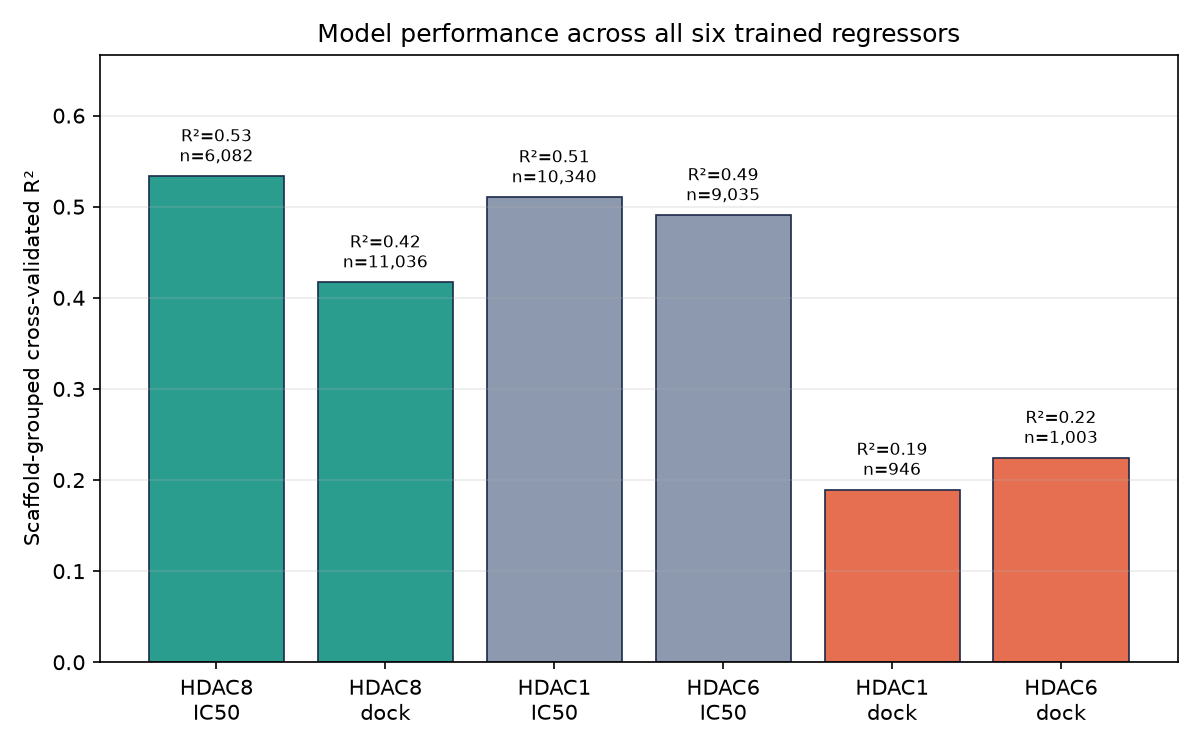

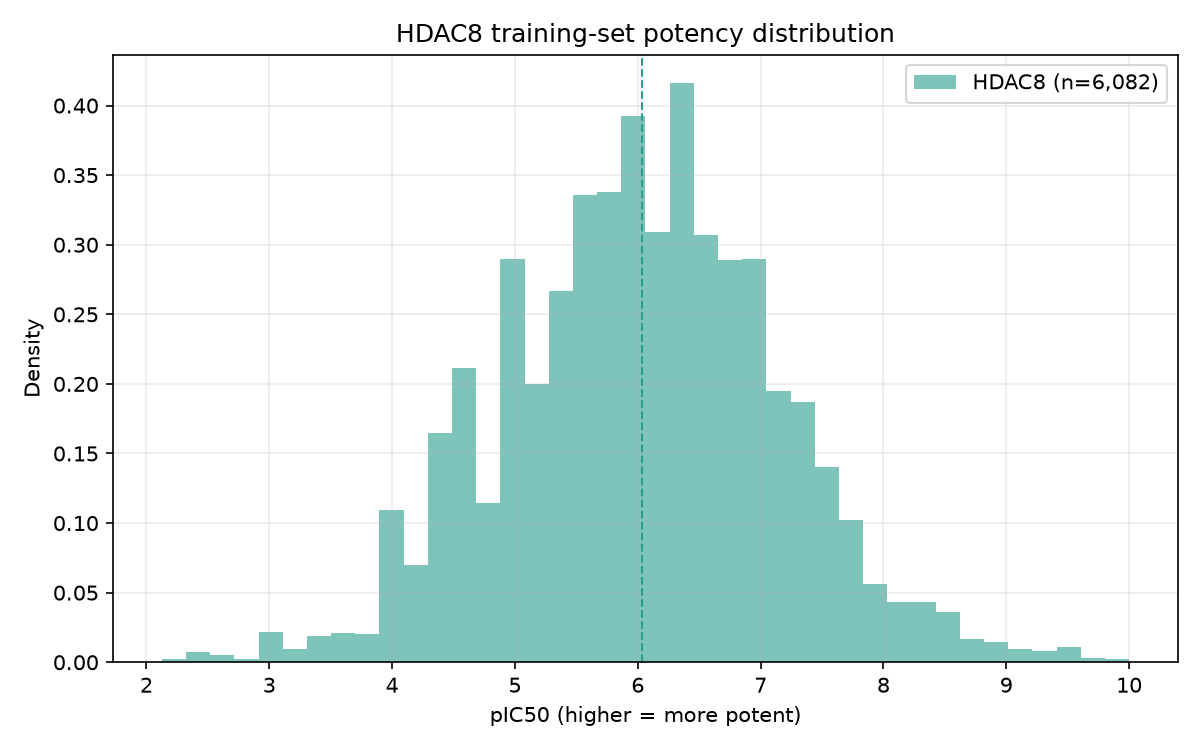

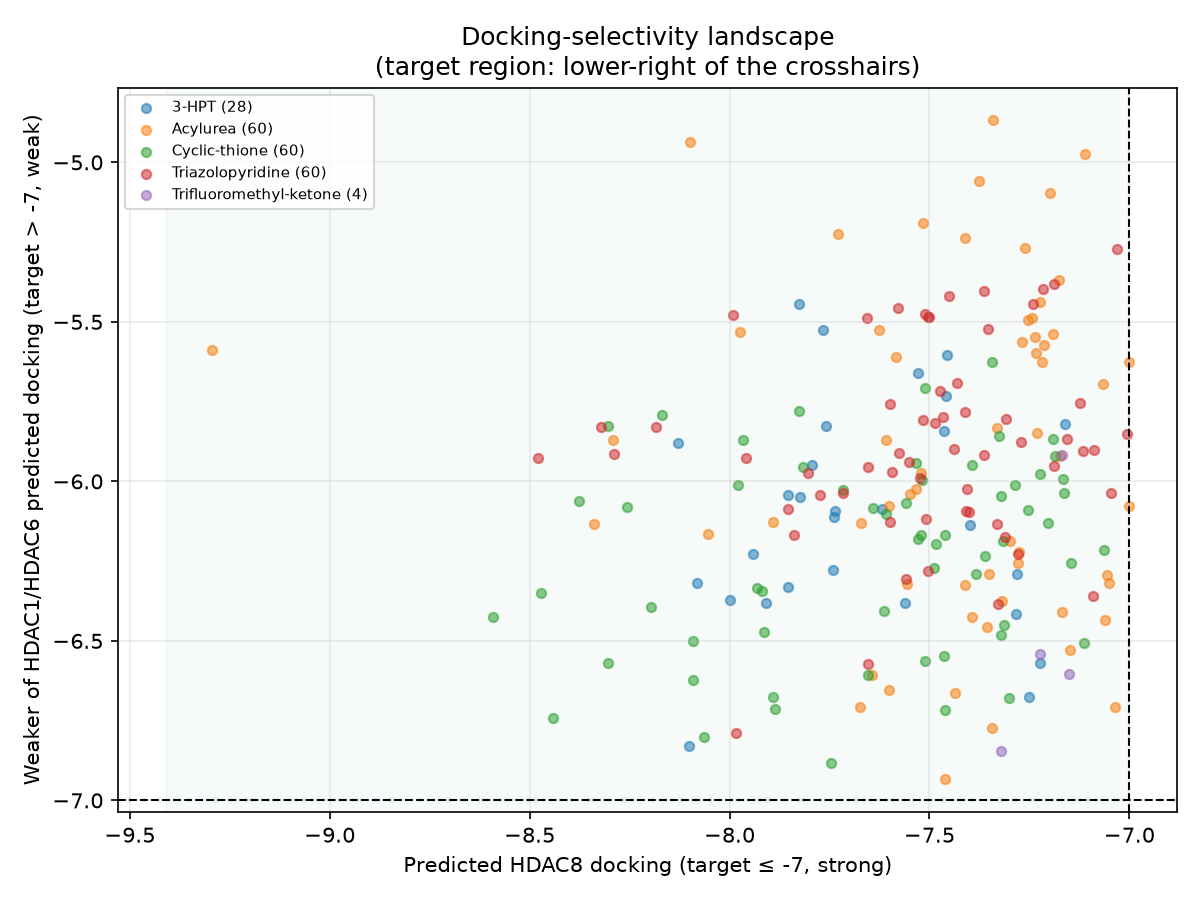

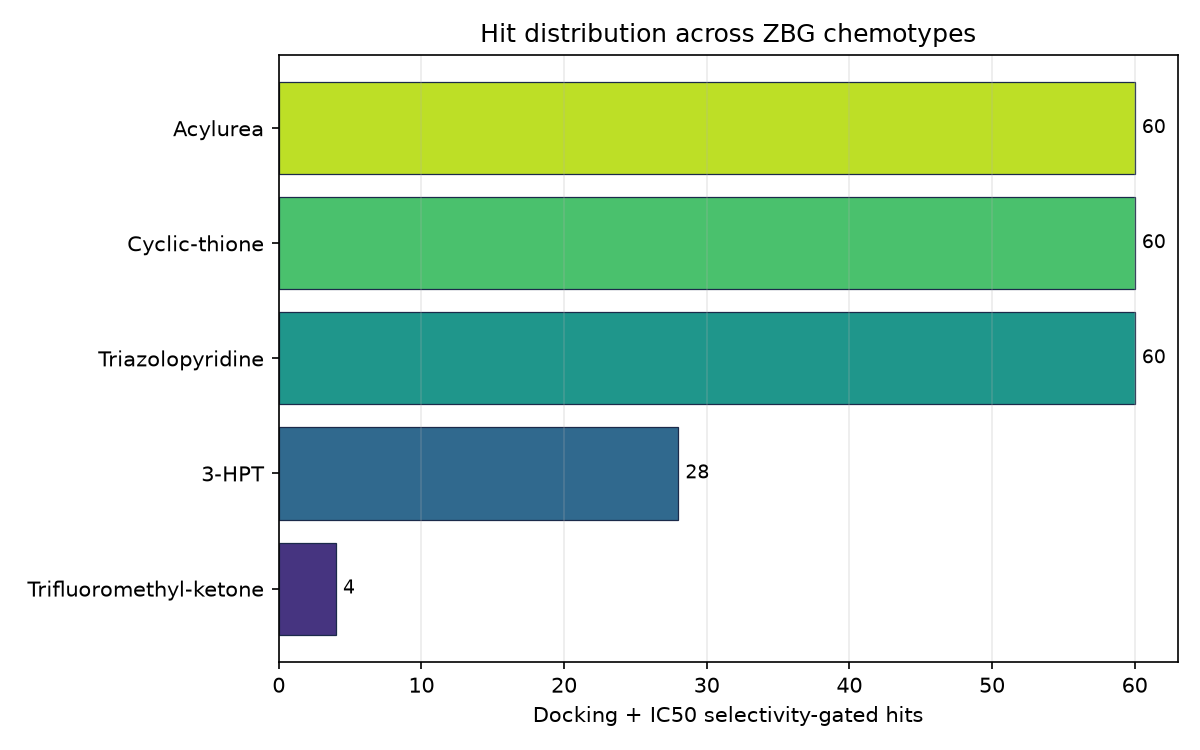

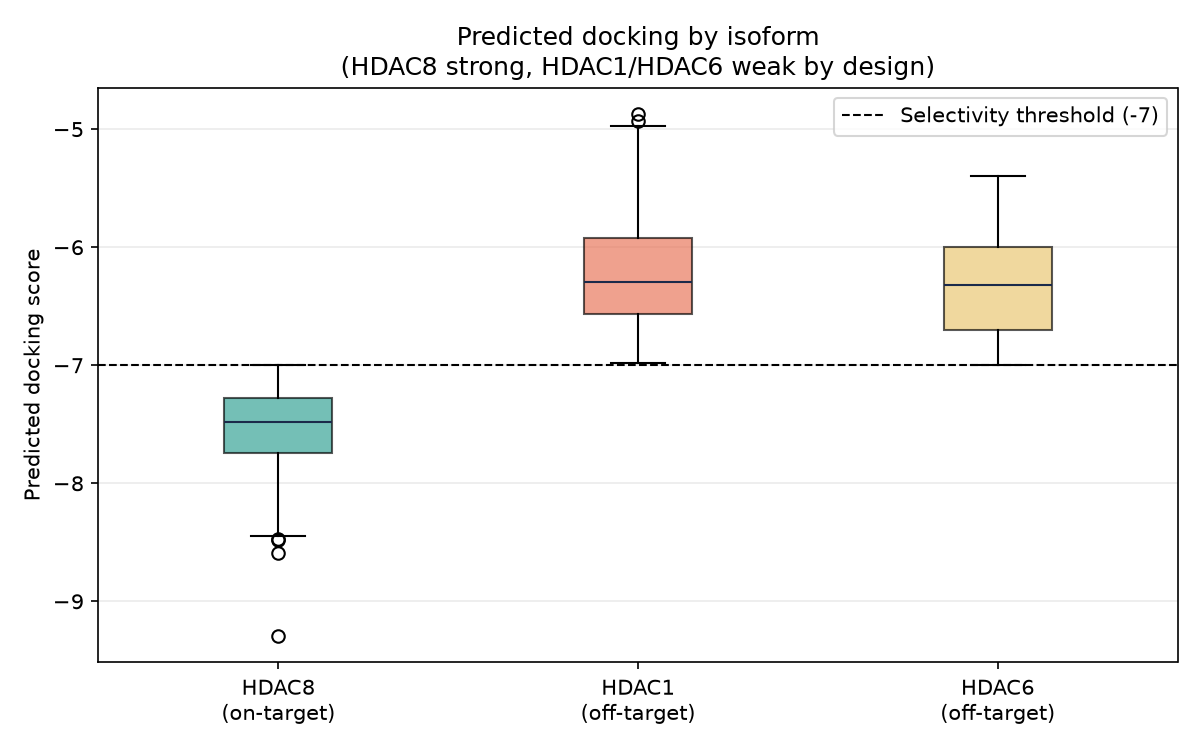

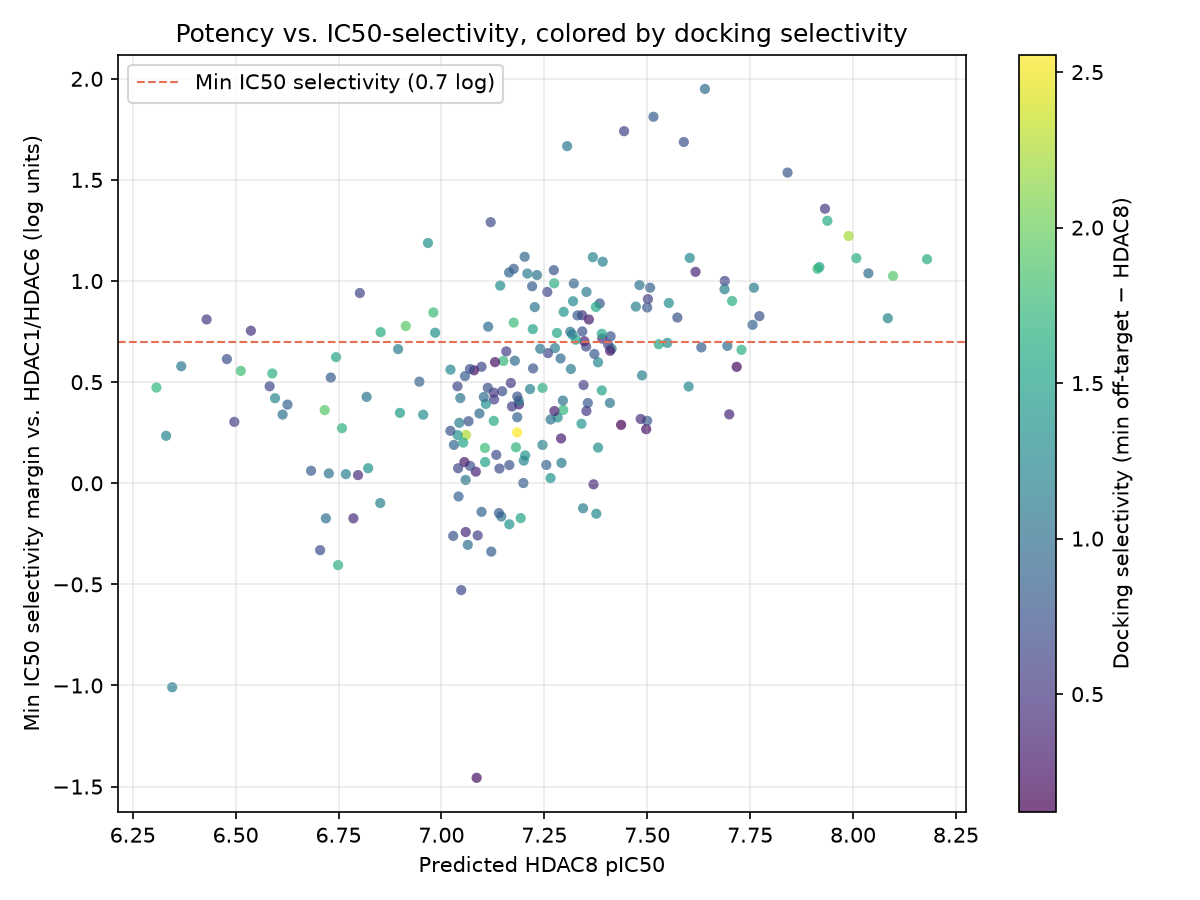

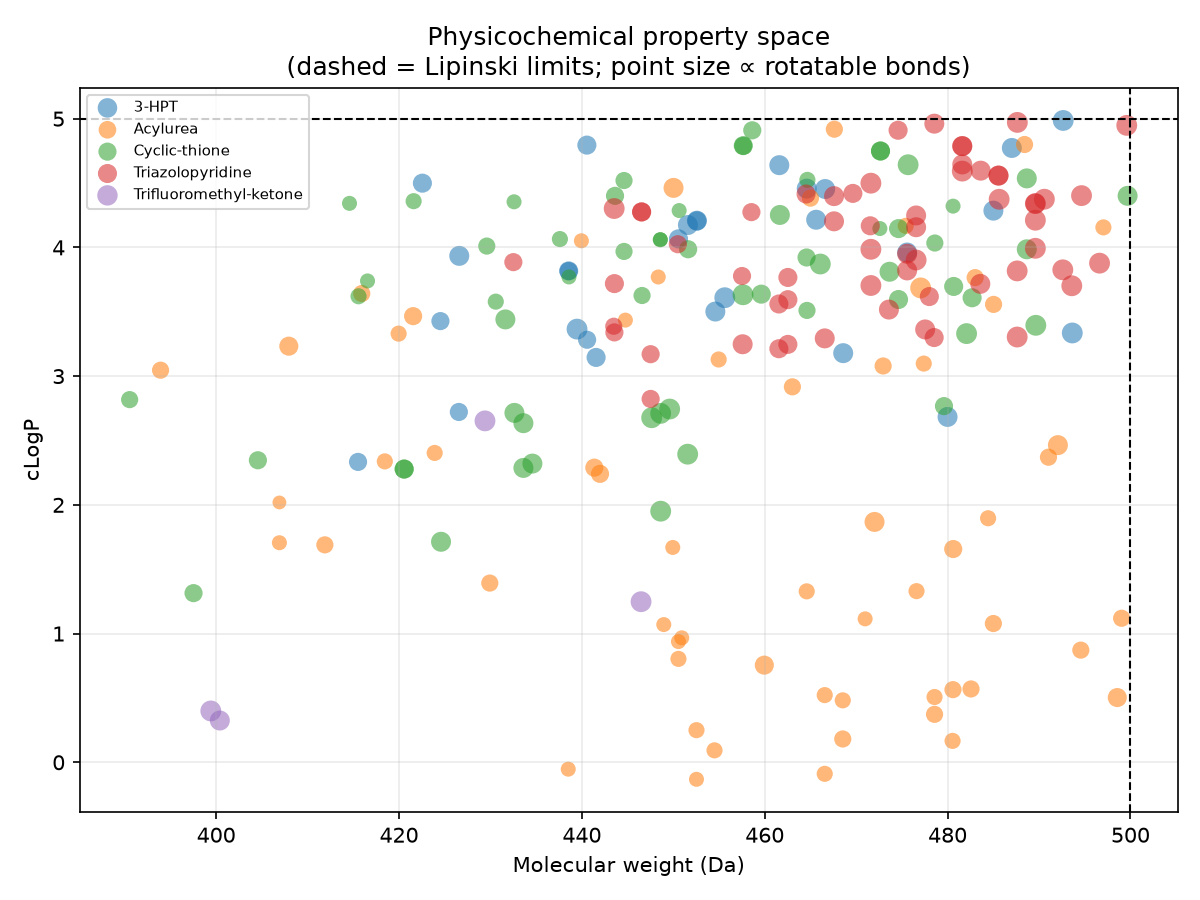

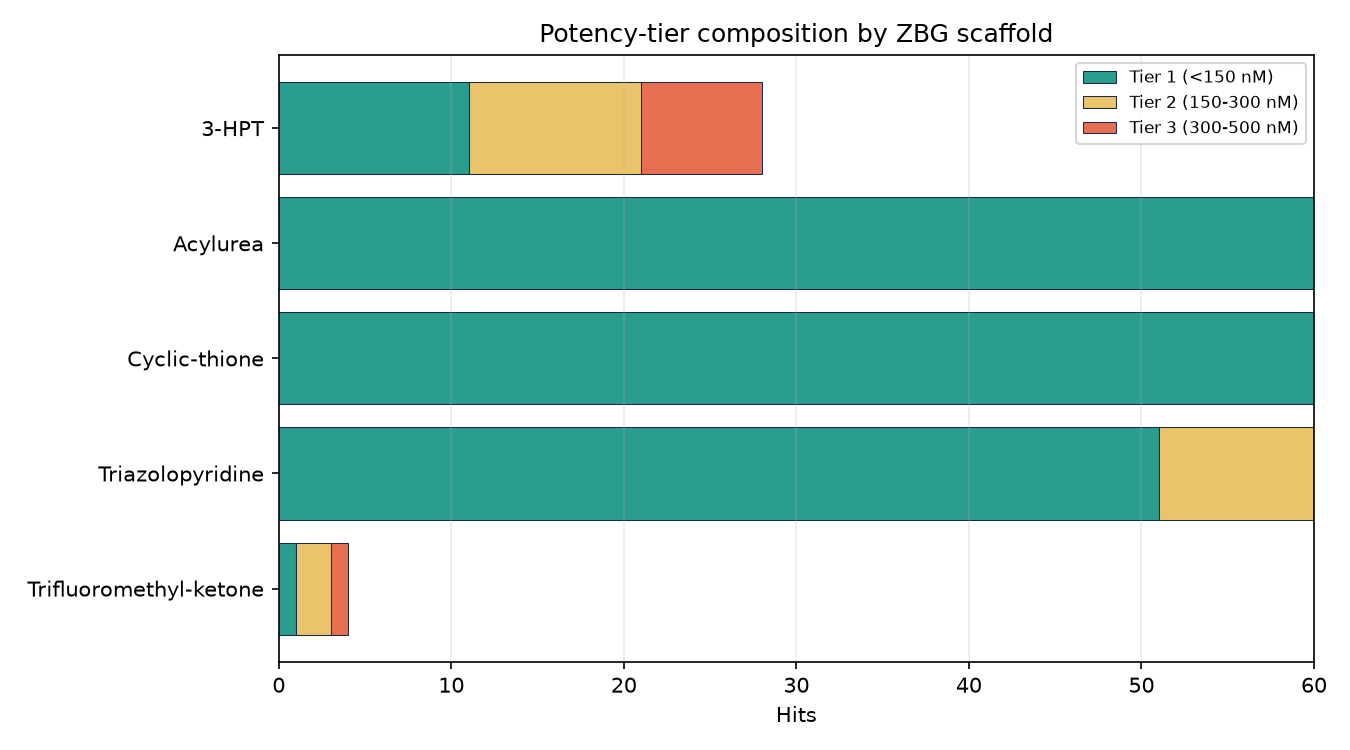

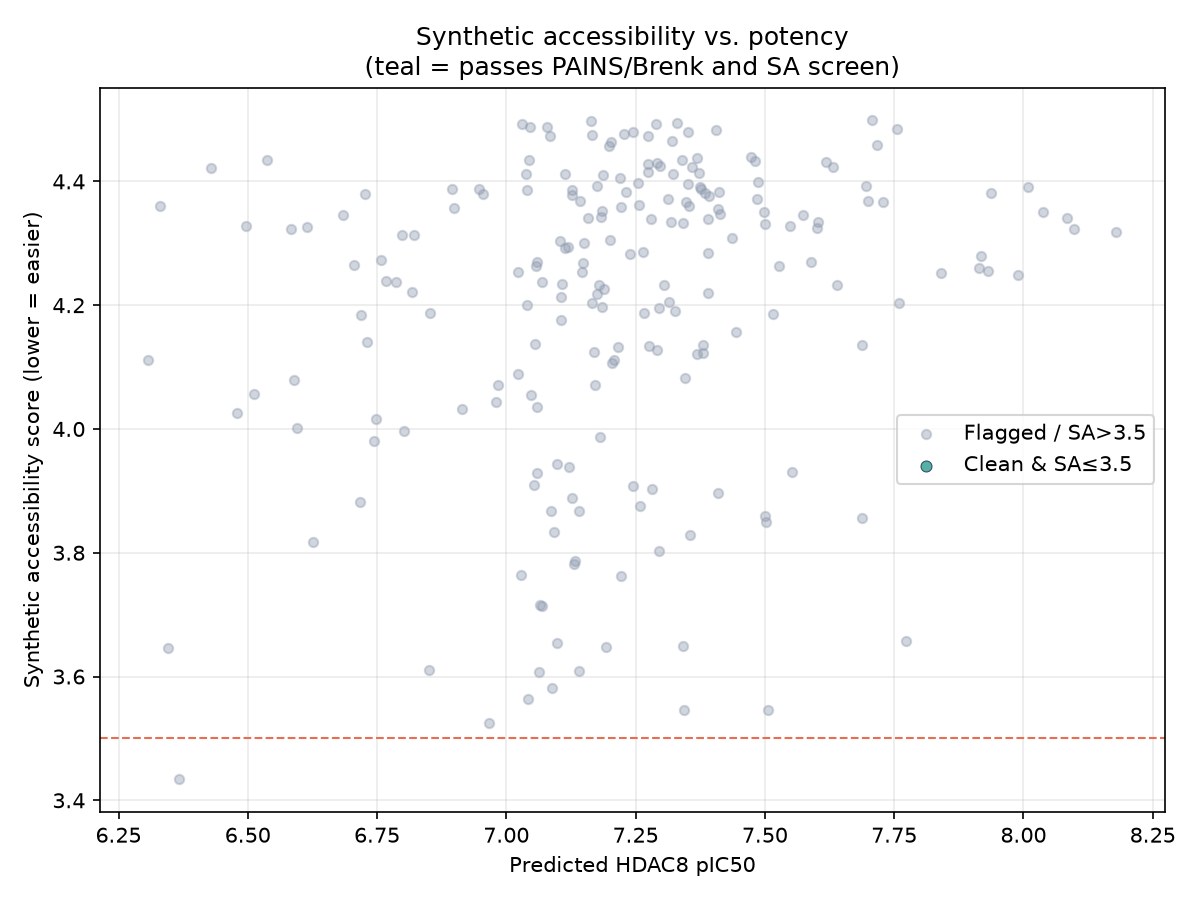

In [16]:
import make_figures
from IPython.display import Image, display

# Generate all nine figures from the candidate CSVs + model bundles.
fig_names = make_figures.make_all_figures(
    cand_dir=os.path.join('..', 'candidates'),
    models_dir=os.path.join('..', 'models'),
    fig_dir=os.path.join('..', 'figures'))
print("Wrote:", fig_names)

# Display them inline in order.
fig_files = [
    'fig1_model_performance.png', 'fig2_training_pic50_dist.png',
    'fig3_docking_selectivity_landscape.png', 'fig4_zbg_distribution.png',
    'fig5_docking_by_target.png', 'fig6_potency_vs_selectivity.png',
    'fig7_property_space.png', 'fig8_tier_by_scaffold.png', 'fig9_sa_vs_potency.png']
for fn in fig_files:
    display(Image(filename=os.path.join('..', 'figures', fn)))

## 9. Top candidates

In [17]:
cols = ['SMILES','zbg_tag','pIC50_pred','IC50_nM_est','IC50_tier',
        'docking_pred','docking_hdac1_pred','docking_hdac6_pred','docking_selectivity',
        'sa_score','exceeds_real_precedent']
full_df.sort_values('docking_selectivity', ascending=False)[cols].head(15)


,SMILES,zbg_tag,pIC50_pred,IC50_nM_est,IC50_tier,docking_pred,docking_hdac1_pred,docking_hdac6_pred,docking_selectivity,sa_score,exceeds_real_precedent
115,CC(CC#N)C1C(NC(=O)NC(=O)c2ccc(Cc3ccccc3)c(Cl)c...,Acylurea,7.183997,65.464009,Tier 1 (<150 nM),-9.294523,-5.589026,-6.737973,2.556550,4.342010,False
156,N#CCCCCC(Cc1c[nH]c2cc(C#N)ccc12)C(c1cccn2cnnc1...,Triazolopyridine,7.059834,87.129556,Tier 1 (<150 nM),-8.479190,-6.217842,-5.926605,2.261348,3.928362,False
5,N#CCCC(Cc1c[nH]c2cc(F)ccc12)C(c1cccn2cnnc12)N1...,Triazolopyridine,7.989411,10.246806,Tier 1 (<150 nM),-7.992542,-5.775002,-5.478472,2.217540,4.249144,False
178,N#CCCCCCC(Cc1ccc(C#N)cc1N1CCOC(O)C1)n1cccc(O)c1=S,3-HPT,6.913414,122.063451,Tier 1 (<150 nM),-8.128532,-6.200759,-5.880502,1.927774,4.031830,True
195,CCNCCCC(Cc1c[nH]c2cc(C#N)ccc12)C(c1cccn2cnnc12...,Triazolopyridine,6.716416,192.125252,Tier 2 (150-300 nM),-7.958462,-5.928081,-6.039927,1.918534,3.881950,False
1,N#CCCCCC(Cc1c[nH]c2cc(F)ccc12)C(c1cccn2cnnc12)...,Triazolopyridine,8.097218,7.994324,Tier 1 (<150 nM),-7.655498,-5.754243,-5.488807,1.901255,4.322610,False
204,CC(=O)C1CN(c2cc(C#N)ccc2CC(CCCCC#N)n2cccc(O)c2...,3-HPT,6.512594,307.189329,Tier 3 (300-500 nM),-7.854071,-6.041722,-6.047829,1.806243,4.056667,True
143,CC1CN(C(c2cccn3cnnc23)C(CCCCC#N)Cc2c[nH]c3cc(C...,Triazolopyridine,7.105697,78.397562,Tier 1 (<150 nM),-8.184480,-6.403833,-5.829244,1.780647,4.213557,False
119,CC(CCC#N)CC(Cc1c[nH]c2cc(C#N)ccc12)C(c1cccn2cn...,Triazolopyridine,7.175556,66.748860,Tier 1 (<150 nM),-8.321535,-6.547493,-5.828682,1.774042,4.217828,False
174,N#CCCCCC(Cc1ccc(C#N)cc1N1CCOC(O)C1)n1cccc(O)c1=S,3-HPT,6.980509,104.590271,Tier 1 (<150 nM),-8.080252,-6.322652,-6.318577,1.757600,4.043711,True


## 10. Predict from SMILES

Score any SMILES (or list of SMILES) against all 6 trained models. Returns HDAC8
on-target predictions, HDAC1/HDAC6 off-target predictions (both IC50 and docking),
selectivity metrics, docking-selectivity gate status, drug-likeness flags, and
applicability-domain confidence.


In [18]:
def predict_from_smiles(smiles_list, sort_by='pIC50_pred'):
    """Score a list of SMILES (or a single SMILES string) against every trained
    model and return one tidy DataFrame row per compound.

    Columns include:
      - identity:      SMILES, valid, zbg_tag
      - HDAC8:         pIC50_pred, IC50_nM_est, docking_pred
      - HDAC1:         pIC50_hdac1_pred, IC50_hdac1_nM_est, docking_hdac1_pred, selectivity_vs_hdac1
      - HDAC6:         pIC50_hdac6_pred, IC50_hdac6_nM_est, docking_hdac6_pred, selectivity_vs_hdac6
      - selectivity:   docking_selectivity, passes_dock_gate
      - safety:        passes_lipinski_veber, sa_score, is_hydroxamate, pains_brenk_flagged,
                       hard_metabolic_liability, soft_metabolic_liability, hydrazide_liability,
                       nn_liability, passes_tier1_gates, tier1_fail_reason
      - confidence:    ic50_model_max_similarity, ic50_model_low_confidence, ic50_model_ad_reject,
                       dock_model_max_similarity, dock_model_low_confidence, dock_model_ad_reject

    Positive selectivity_vs_hdac1/6 = predicted to hit HDAC8 harder than that off-target.
    Positive docking_selectivity = HDAC8 docks stronger than both off-targets.
    passes_dock_gate = HDAC8 dock <= -7 and both off-target docks > -7.
    """
    if isinstance(smiles_list, str):
        smiles_list = [smiles_list]

    results = predict_batch(
        smiles_list, ic50_bundle, dock_bundle,
        hdac1_bundle=hdac1_bundle, hdac6_bundle=hdac6_bundle,
        hdac1_dock_bundle=hdac1_dock_bundle, hdac6_dock_bundle=hdac6_dock_bundle,
    )
    df = pd.DataFrame(results)

    # Add docking-selectivity gate flag
    def gate_row(row):
        d8 = row.get('docking_pred')
        d1 = row.get('docking_hdac1_pred')
        d6 = row.get('docking_hdac6_pred')
        if d8 is None or pd.isna(d8): return None
        return passes_docking_selectivity_gate(d8, d1, d6)
    df['passes_dock_gate'] = df.apply(gate_row, axis=1)

    column_order = [
        'SMILES', 'valid', 'zbg_tag',
        'pIC50_pred', 'IC50_nM_est', 'docking_pred',
        'pIC50_hdac1_pred', 'IC50_hdac1_nM_est', 'docking_hdac1_pred', 'selectivity_vs_hdac1',
        'pIC50_hdac6_pred', 'IC50_hdac6_nM_est', 'docking_hdac6_pred', 'selectivity_vs_hdac6',
        'docking_selectivity', 'passes_dock_gate',
        'passes_lipinski_veber', 'sa_score', 'is_hydroxamate', 'pains_brenk_flagged',
        'hard_metabolic_liability', 'soft_metabolic_liability', 'hydrazide_liability', 'nn_liability',
        'passes_tier1_gates', 'tier1_fail_reason',
        'ic50_model_max_similarity', 'ic50_model_low_confidence', 'ic50_model_ad_reject',
        'dock_model_max_similarity', 'dock_model_low_confidence', 'dock_model_ad_reject',
    ]
    df = df[[c for c in column_order if c in df.columns]]
    if sort_by and sort_by in df.columns and df['valid'].any():
        df = df.sort_values(sort_by, ascending=False, na_position='last').reset_index(drop=True)
    return df

print("predict_from_smiles() defined — pass any SMILES or list of SMILES.")


predict_from_smiles() defined — pass any SMILES or list of SMILES.


### Example usage

Swap in your own SMILES below. Works for one compound or a batch.

In [19]:
# Score two balanced-deliverable hits + vorinostat/SAHA (hydroxamate → Tier-1 rejection)
example_smiles = list(balanced['SMILES'].head(2)) + ['ONC(=O)/C=C/c1ccc(CNC(=O)c2ccccc2)cc1']
predict_from_smiles(example_smiles)


,SMILES,valid,zbg_tag,pIC50_pred,IC50_nM_est,docking_pred,pIC50_hdac1_pred,IC50_hdac1_nM_est,docking_hdac1_pred,selectivity_vs_hdac1,...,hydrazide_liability,nn_liability,passes_tier1_gates,tier1_fail_reason,ic50_model_max_similarity,ic50_model_low_confidence,ic50_model_ad_reject,dock_model_max_similarity,dock_model_low_confidence,dock_model_ad_reject
0,CC(=O)NC(CCCCC#N)c1nnn(Cn2cccc(O)c2=S)c1N1CCOC...,True,3-HPT,7.497458,31.808419,-7.223497,7.229999,58.884507,-6.570700,0.267459,...,False,False,True,NaN,0.415584,False,False,0.231481,True,False
1,N#CCCCCCC(Cc1ccc(C#N)cc1N1CC(O)OC(Cl)C1)n1cccc...,True,3-HPT,7.330649,46.703676,-7.282725,6.500631,315.768743,-6.414500,0.830018,...,False,False,True,NaN,0.366197,False,False,0.205882,True,False
2,ONC(=O)/C=C/c1ccc(CNC(=O)c2ccccc2)cc1,True,Unknown,6.672513,212.562895,-7.689213,6.874978,133.359009,-7.224687,-0.202465,...,False,False,False,hydroxamate,0.780488,False,False,0.560976,False,False


## 11. Save run state

Saves everything needed to reload results later without re-running the GA.


In [20]:
with open(os.path.join('..', 'models', 'docking_selective_run_state.pkl'), 'wb') as f:
    pickle.dump({
        'hits_df': full_df, 'balanced': balanced, 'reps': reps,
        'final_screen': final_screen,
        'ic50_bundle': ic50_bundle, 'dock_bundle': dock_bundle,
        'hdac1_bundle': hdac1_bundle, 'hdac6_bundle': hdac6_bundle,
        'hdac1_dock_bundle': hdac1_dock_bundle, 'hdac6_dock_bundle': hdac6_dock_bundle,
    }, f)
print("Saved docking_selective_run_state.pkl")


Saved docking_selective_run_state.pkl
